<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day07_resnet_dissection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Computer Vision, Fall 2026

Tuesday, September 15, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# **Creating ResNet network architecture**
> ## **Loading model's pretrained weights from PyTorch library**

In [11]:
import torch
import torch.nn as nn
from torchvision import models
import pdb

import PIL
from PIL import Image
import json
import torch
import torchvision
import torchvision.transforms as T

import sys
import matplotlib.pyplot as plt
import scipy.io
import os

import numpy as np

from torchvision import transforms, datasets



class ResNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(ResNet, self).__init__()

        # download PyTorch's own implementation of VGG model trained on ImageNet dataset
        net = models.resnet18(pretrained=True)

        # retained weightes for convolutional, maxpooling, and linear layers from ResNet
        self.conv1    = net.conv1
        self.bn1      = net.bn1
        self.relu     = net.relu
        self.maxpool  = net.maxpool

        self.layer1   = net.layer1
        self.layer2   = net.layer2
        self.layer3   = net.layer3
        self.layer4   = net.layer4

        self.avgpool  = net.avgpool
        self.fc       = net.fc

        # IMPORTANT: "If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated ResNet has the desired number of output classes: 'num_classes'
        # self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch


    def forward(self, x):

        print("shape of input: ", x.shape)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        print("output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        print("output shape (self.fc): ", x.shape)

        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)
number_of_classes = 1000
model             = ResNet(number_of_classes)
model.to(device)


device =  cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Doing single forward pass on ResNet-50 using a sample image**

### **Run the pretrained model on a random image to test its classification ability**
> I have uploaded the images of `cat,` `dog,` and `bike` to Blackboard.

> You can download those images and upload them to your workspace. Alternatively, you can download random images of a `cat,` `dog,` or `any other class of your choice` and test them using ResNet.


[width, height] of the image: [800, 534]


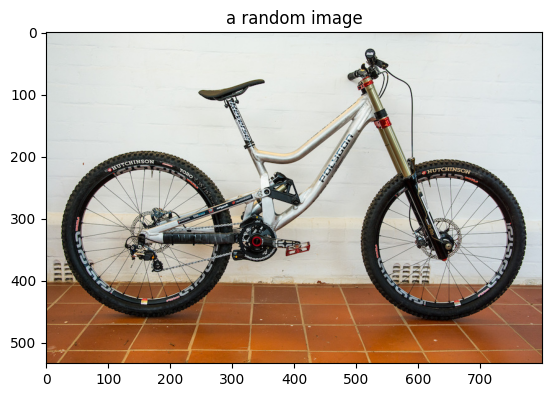

In [12]:
# your code
# ...
# ...
# ...

import PIL
from PIL import Image
TEST_IMAGE_DIR  = '/content/drive/MyDrive/cs181_fall26/module_3_classification/images/'
image_name_list = ['random_dog1.jpg',
                   'random_dog2.jpg',
                   'random_cat1.jpg',
                   'random_cat2.jpg',
                   'random_bike1.jpg'
                   ]
index           = 4
img             = PIL.Image.open(TEST_IMAGE_DIR + '/' + image_name_list[index])
print(f"[width, height] of the image: [{img.size[0]}, {img.size[1]}]")
plt.imshow(img)
plt.title("a random image")
plt.show()

##**Transform the image by resizing + normalizing it with ImageNet mean**


In [13]:
from torchvision import transforms


# util function:
def get_imagenet_mean_std_normalized():
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std

mean, std           = get_imagenet_mean_std_normalized()
print(f"ImageNet: mean: {mean}, std: {std}")

# CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.

TEST_IMAGE_SIZE_W   = 227
TEST_IMAGE_SIZE_H   = 227

transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std) # ImageNet: mean (R, G, B) and standard deviation (R, G, B)
])

img_tensor          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_tensor.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_tensor.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_tensor.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_tensor.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_tensor.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_tensor.shape[0]}x{img_tensor.shape[1]}x{img_tensor.shape[2]}x{img_tensor.shape[3]}")




ImageNet: mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 227, 227])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         227
WIDTH_SIZE:          227
Summary: [how_many, channel, height, width] of the image tensor: 1x3x227x227


In [14]:
raw_output          = model(img_tensor)
output_prob         = torch.softmax(raw_output, dim=1)
#output_prob_numpy   = output_prob.data.numpy()[0] # do this line instead of the next when your are connected to GPU
output_prob_numpy   = output_prob.data.cpu().numpy()[0]


shape of input:  torch.Size([1, 3, 227, 227])
output shape (self.avgpool):  torch.Size([1, 512, 1, 1])
output shape (self.fc):  torch.Size([1, 1000])
